In [33]:
import earthaccess
import xarray as xr
import rioxarray
import rasterio as rio
import numpy as np
import os

import re
from urllib.parse import urlparse
from datetime import datetime
from pathlib import PurePosixPath

# requires pip-system-certs
auth = earthaccess.login(strategy='interactive', persist=True) # authentication 

Enter here the main parameters of your search and preprocessing.

In [34]:
AOI = 'Mera'

Zones = {
    'Mera': ((86.80148,27.64484, 86.94120,27.75825), 'EPSG:4326'),     # projection EPSG:4623
} # Area you want to crop and download, ((lon_min, lat_min, lon_max, lat_max), Projection)

temp_extent = ('2025-11-15', '2026-01-31')

FILTERS = ['120_D', 'QPDH'] # Filters you want to apply to the data search (relative orbit number, A or D (ascending or Descending)... see documentation) 
# relative orbits: 048_D, 120_D...
# polarisation: QPDH, DHDH

group_path = "/science/LSAR/GCOV/grids/frequencyA" # Path to a product, frequancyA has quadpol, B as Dual pol
BOI = ['HHHH', 'HVHV', 'VVVV', 'VHVH'] # Bands of interest, see documentation for more exemples

Save_path = f'./Data/NISAR_GCOV/{AOI}'

spatial_extent = Zones[AOI][0]
bbox_crs = Zones[AOI][1]

Fetching data takes a bit, reducing the spatial/temporal extent should make it faster

In [35]:
results = earthaccess.search_data(
    short_name='NISAR_L2_GCOV_BETA_V1', # The product to access, there is many more, see doc.
    count=-1, 
    bounding_box=spatial_extent, 
    temporal=temp_extent,
    cloud_hosted=True,
)

# Filtering the URL 
mask = np.where([all(f in result["meta"]['native-id'] for f in FILTERS) for result in results])[0]
results = [results[id] for id in mask]
names = [result["meta"]['native-id'] for result in results]

print(len(results), 'files found') 

# Configuration connection
fsspec_config = {
    'cache_type': 'background',
    'block_size': 16*1024*1024,  # 16 MB
}
fs = earthaccess.get_fsspec_https_session()

https_links = [result.data_links(access='external') for result in results]
files = [fs.open(https_link[0], **fsspec_config) for https_link in https_links]

# Creating a list of datatrees, takes a few minutes
datatrees = [xr.open_datatree(
                f,
                engine='h5netcdf',
                decode_timedelta=False,
                phony_dims="access", 
                chunks = 'auto',
                )[group_path]
for f in files]

/home/desvignese/NISAR/NISAR_GCOV_API/.venv/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


4 files found


# Adding a time dimension

In [36]:
NISAR_TS_RE = re.compile(r"_(\d{8}T\d{6})_")

def nisar_start_time_from_url(url: str) -> datetime:
    path = urlparse(url).path
    name = PurePosixPath(path).name
    
    m = NISAR_TS_RE.search(name)
    if not m:
        raise ValueError(f"No NISAR timestamp found in: {url}")
    
    return datetime.strptime(m.group(1), "%Y%m%dT%H%M%S")

dts = [nisar_start_time_from_url(url[0]) for url in https_links]


In [37]:
%%time

datasets = [
    tree.ds.assign_coords(time=dt).expand_dims(time=1)
    for dt, tree in zip(dts, datatrees)
]

datasets[0]

CPU times: user 73.6 ms, sys: 15.5 ms, total: 89.1 ms
Wall time: 88.7 ms


<xarray.Dataset> Size: 22GB
Dimensions:                (time: 1, yCoordinates: 16956, xCoordinates: 17244,
                            phony_dim_0: 10, phony_dim_1: 4)
Coordinates:
  * time                   (time) datetime64[us] 8B 2025-12-12T12:50:28
  * yCoordinates           (yCoordinates) float64 136kB 3.127e+06 ... 2.788e+06
  * xCoordinates           (xCoordinates) float64 138kB 4.039e+05 ... 7.488e+05
Dimensions without coordinates: phony_dim_0, phony_dim_1
Data variables: (12/19)
    HHHH                   (time, yCoordinates, xCoordinates) float32 1GB dask.array<chunksize=(1, 5632, 5632), meta=np.ndarray>
    HHHV                   (time, yCoordinates, xCoordinates) complex64 2GB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
    HHVH                   (time, yCoordinates, xCoordinates) complex64 2GB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
    HHVV                   (time, yCoordinates, xCoordinates) complex64 2GB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
    HVHV                   (time, yCoordinates, xCoordinates) float32 1GB dask.array<chunksize=(1, 5632, 5632), meta=np.ndarray>
    HVVH                   (time, yCoordinates, xCoordinates) complex64 2GB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
    ...                     ...
    numberOfLooks          (time, yCoordinates, xCoordinates) float32 1GB dask.array<chunksize=(1, 5632, 5632), meta=np.ndarray>
    numberOfSubSwaths      (time) uint8 1B 4
    projection             (time) uint32 4B 32645
    rtcGammaToSigmaFactor  (time, yCoordinates, xCoordinates) float32 1GB dask.array<chunksize=(1, 5632, 5632), meta=np.ndarray>
    xCoordinateSpacing     (time) float64 8B 20.0
    yCoordinateSpacing     (time) float64 8B -20.0

# Projection and croping to the Area

In [38]:
%%time

dataarrays = [
    ds[BOI].to_dataarray(dim="band").assign_coords(projection = ds.projection)
    for ds in datasets
]

dataarrays[0]

CPU times: user 19.5 ms, sys: 0 ns, total: 19.5 ms
Wall time: 19 ms


<xarray.DataArray (band: 4, time: 1, yCoordinates: 16956, xCoordinates: 17244)> Size: 5GB
dask.array<stack, shape=(4, 1, 16956, 17244), dtype=float32, chunksize=(1, 1, 5692, 5632), chunktype=numpy.ndarray>
Coordinates:
  * band          (band) object 32B 'HHHH' 'HVHV' 'VVVV' 'VHVH'
  * time          (time) datetime64[us] 8B 2025-12-12T12:50:28
    projection    (time) uint32 4B 32645
  * yCoordinates  (yCoordinates) float64 136kB 3.127e+06 3.127e+06 ... 2.788e+06
  * xCoordinates  (xCoordinates) float64 138kB 4.039e+05 4.04e+05 ... 7.488e+05

In [39]:
dataarrays_proj =  [da.rio.write_crs(f"EPSG:{da.isel(time=0).projection.item()}") for da in dataarrays]

bbox4326 = dict(minx=spatial_extent[0], miny=spatial_extent[1], maxx=spatial_extent[2], maxy=spatial_extent[3], crs=bbox_crs)
da_subset = [da.rio.clip_box(**bbox4326) for da in dataarrays_proj]

In [40]:
ts = xr.concat(da_subset, dim="time")
ts

<xarray.DataArray (band: 4, time: 4, yCoordinates: 629, xCoordinates: 691)> Size: 28MB
dask.array<concatenate, shape=(4, 4, 629, 691), dtype=float32, chunksize=(1, 1, 629, 691), chunktype=numpy.ndarray>
Coordinates:
  * band          (band) object 32B 'HHHH' 'HVHV' 'VVVV' 'VHVH'
  * time          (time) datetime64[us] 32B 2025-12-12T12:50:28 ... 2026-01-1...
    projection    (time) uint32 16B 32645 32645 32645 32645
  * yCoordinates  (yCoordinates) float64 5kB 3.07e+06 3.07e+06 ... 3.058e+06
  * xCoordinates  (xCoordinates) float64 6kB 4.804e+05 4.804e+05 ... 4.942e+05
    spatial_ref   int64 8B 0

# Saving the h5 file
For this instance, takes about 5 minutes for a 27 Mo file

In [41]:
ts.to_netcdf(os.path.join(Save_path, '_'.join(FILTERS) + '.h5'))

# Opening and reading presaved Data

In [43]:
NISAR = xr.load_dataset(os.path.join(Save_path, '_'.join(FILTERS) + '.h5'))

NISAR = NISAR.__xarray_dataarray_variable__
NISAR

<xarray.DataArray '__xarray_dataarray_variable__' (band: 4, time: 4,
                                                   yCoordinates: 629,
                                                   xCoordinates: 691)> Size: 28MB
array([[[[0.60985565, 0.2881775 , 0.29268646, ..., 0.18776894,
          0.35299683, 0.30400848],
         [0.28764343, 0.37277603, 0.16050339, ..., 0.34038925,
          0.2827835 , 0.10419178],
         [0.09622097, 0.41959   , 0.6520462 , ..., 0.26031494,
          0.5774536 , 0.3215065 ],
         ...,
         [0.05085421, 0.07884789, 0.3741455 , ..., 0.09125137,
          0.23097038, 0.2479477 ],
         [0.13811111, 0.33554077, 0.5261307 , ..., 0.1789093 ,
          0.07412529, 0.09774685],
         [0.11816883, 0.11130333, 0.2926979 , ..., 0.14543343,
          0.28640366, 0.18408966]],

        [[0.6656952 , 0.2200489 , 0.26451874, ..., 0.15072632,
          0.45162582, 0.2144165 ],
         [0.7209625 , 0.9779358 , 0.66604614, ..., 0.20787048,
          0.21971703, 0.15035248],
         [0.19905853, 0.44724274, 0.60472107, ..., 0.28326035,
          0.228199  , 0.22137642],
...
          0.01554573, 0.01795053],
         [0.02020741, 0.07313061, 0.09439468, ..., 0.01786709,
          0.03012419, 0.01693797],
         [0.02488637, 0.03082967, 0.09104443, ..., 0.0410409 ,
          0.04472065, 0.03299856]],

        [[0.03474998, 0.03081393, 0.03628778, ..., 0.02813816,
          0.05630302, 0.06559372],
         [0.01756954, 0.02275729, 0.03393698, ..., 0.0563736 ,
          0.03982306, 0.03777456],
         [0.03962326, 0.02639008, 0.03700924, ..., 0.06424618,
          0.07528496, 0.05840349],
         ...,
         [0.01507735, 0.05483246, 0.13850021, ..., 0.01623416,
          0.0193975 , 0.02961349],
         [0.01834822, 0.09454727, 0.44007874, ..., 0.02789116,
          0.01588488, 0.01971269],
         [0.04463243, 0.04981661, 0.14311028, ..., 0.02412033,
          0.02887917, 0.02365446]]]],
      shape=(4, 4, 629, 691), dtype=float32)
Coordinates:
  * band          (band) <U4 64B 'HHHH' 'HVHV' 'VVVV' 'VHVH'
  * time          (time) datetime64[ns] 32B 2025-12-12T12:50:28 ... 2026-01-1...
    projection    (time) uint32 16B 32645 32645 32645 32645
  * yCoordinates  (yCoordinates) float64 5kB 3.07e+06 3.07e+06 ... 3.058e+06
  * xCoordinates  (xCoordinates) float64 6kB 4.804e+05 4.804e+05 ... 4.942e+05
Attributes:
    grid_mapping:  spatial_ref

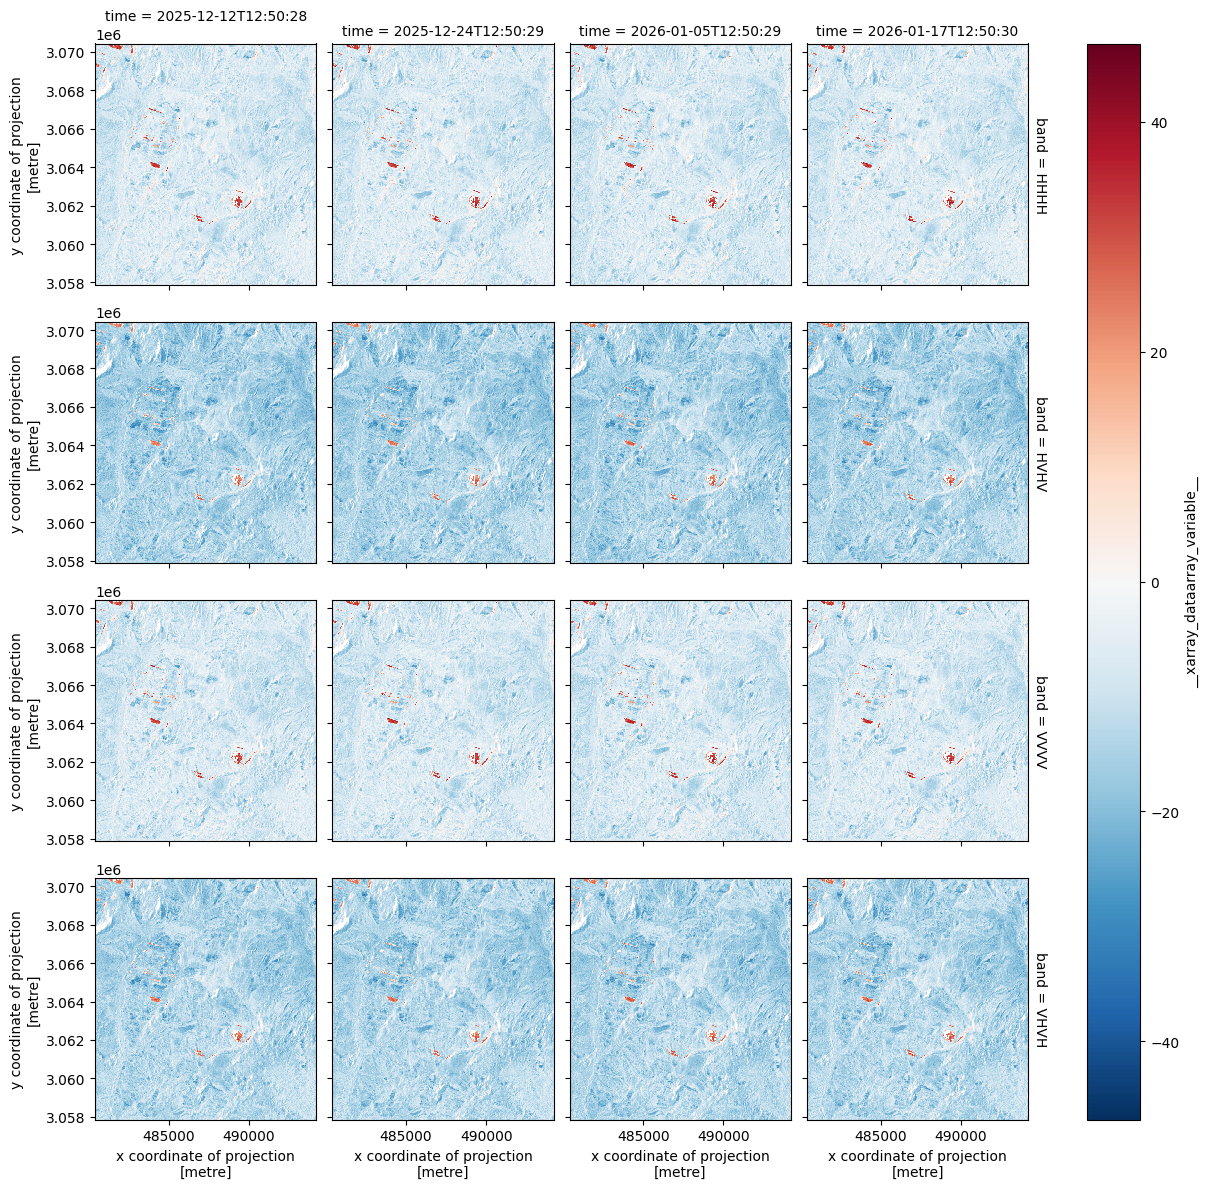

In [44]:
NISAR_dB = 10 * np.log10(NISAR.where(NISAR>0))
NISAR_dB.plot.pcolormesh(col='time', row='band')